# Breast Cancer Classification Using Machine Learning

## Project Overview

This project develops and evaluates machine learning models for classifying breast tumors as malignant or benign using the Breast Cancer Wisconsin Diagnostic dataset.

The project follows a complete machine learning workflow, including:

- Data loading and exploration
- Data preprocessing
- Train-test splitting
- Model development using machine learning pipelines
- Model evaluation and comparison
- ROC curve analysis
- Best model selection
- Feature importance analysis

Five classification models are evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine

Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

RANDOM_STATE = 42

## 2. Load the Dataset

The Breast Cancer Wisconsin Diagnostic dataset is loaded using Scikit-learn.

The dataset contains features computed from digitized images of breast mass cell nuclei. The target variable represents two classes: malignant and benign.

In [2]:
# Load the dataset
data = load_breast_cancer()

# Create a DataFrame from the feature data
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target variable
df["target"] = data.target

# Display the first five rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Understanding the Target Classes

In [3]:
# Display target class names
print("Target classes:", data.target_names)

# Display the class distribution
print("\nClass distribution:")
print(df["target"].value_counts())

Target classes: ['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


## 4. Initial Data Inspection

This section examines the structure and basic characteristics of the dataset, including its dimensions, data types, and missing values.

In [4]:
# Display the dataset dimensions
print("Dataset shape:", df.shape)

# Display column data types and non-null counts
df.info()

Dataset shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  s

## 5. Exploratory Data Analysis

### Target Class Distribution

This visualization shows the distribution of malignant and benign cases in the dataset.

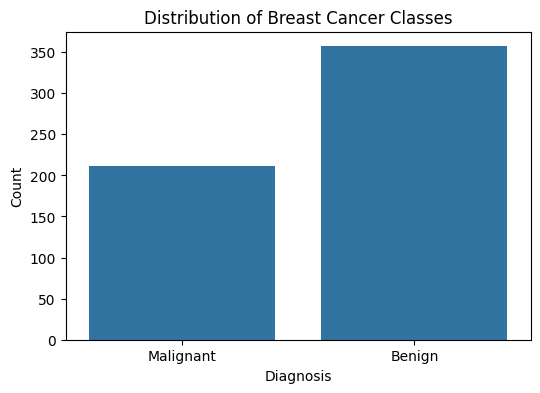

In [5]:
# Map target values to class names for visualization
target_labels = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

plt.figure(figsize=(6, 4))
sns.countplot(x=target_labels)

plt.title("Distribution of Breast Cancer Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

### Feature Correlation with the Target

The correlation between each numerical feature and the target variable is examined to identify features with stronger linear relationships with the diagnosis.

In [6]:
# Calculate correlations between each feature and the target variable
target_correlation = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values()
)

target_correlation

,target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


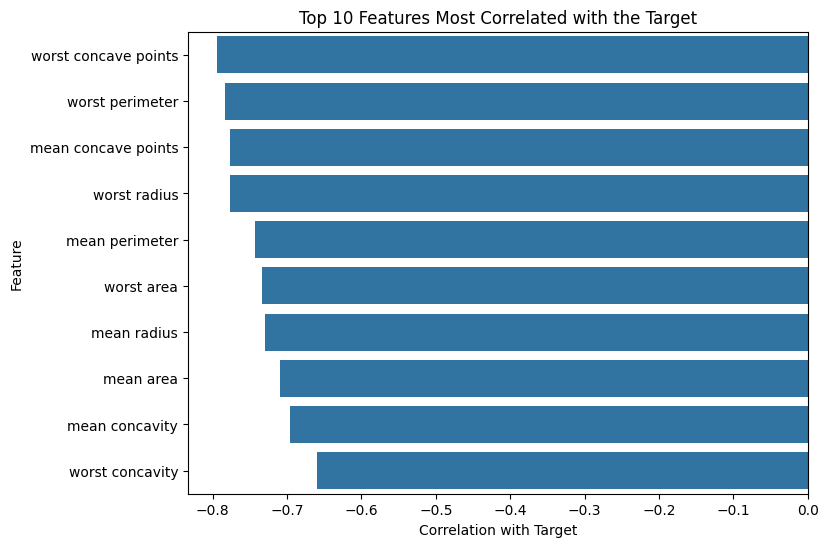

In [7]:
# Select the 10 features with the strongest absolute correlations
top_features = (
    target_correlation
    .abs()
    .nlargest(10)
    .index
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=target_correlation[top_features].sort_values().values,
    y=target_correlation[top_features].sort_values().index
)

plt.title("Top 10 Features Most Correlated with the Target")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")

plt.show()

## 6. Data Preparation

The dataset is separated into input features and the target variable before training the machine learning models.

In [8]:
# Separate input features from the target variable
X = df.drop("target", axis=1)
y = df["target"]

### Train-Test Split

The dataset is divided into training and test sets.

The test set is kept separate and is used only for the final evaluation of the selected model.

In [9]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


## 7. Model Pipelines

Machine learning pipelines are used to combine preprocessing and model training into a single workflow.

Feature scaling is applied to models that are sensitive to the scale of the input features, including Logistic Regression, K-Nearest Neighbors, and Support Vector Machine.

In [10]:
# Define the machine learning models
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            SVC(
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ])
}

## 8. Cross-Validation and Model Comparison

### Cross-Validation Setup

Stratified 5-fold cross-validation is used to preserve the class distribution across validation folds.

In [11]:
# Define stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

Define Custom Scoring Functions

In [12]:
def malignant_precision(estimator, X, y):
    """
    Calculate precision with Malignant treated as
    the positive class.
    """

    y_pred = estimator.predict(X)

    return precision_score(
        y,
        y_pred,
        pos_label=0
    )


def malignant_recall(estimator, X, y):
    """
    Calculate recall with Malignant treated as
    the positive class.
    """

    y_pred = estimator.predict(X)

    return recall_score(
        y,
        y_pred,
        pos_label=0
    )


def malignant_f1(estimator, X, y):
    """
    Calculate the F1-score with Malignant treated
    as the positive class.
    """

    y_pred = estimator.predict(X)

    return f1_score(
        y,
        y_pred,
        pos_label=0
    )


def malignant_roc_auc(estimator, X, y):
    """
    Calculate ROC-AUC using the predicted
    probability of the Malignant class.
    """

    # Convert the target so that:
    # 1 = Malignant
    # 0 = Benign
    y_malignant = (y == 0).astype(int)

    # Extract the probability of the Malignant class
    y_prob_malignant = estimator.predict_proba(X)[:, 0]

    return roc_auc_score(
        y_malignant,
        y_prob_malignant
    )

Define Scoring Metrics

In [13]:
# Define the evaluation metrics used during cross-validation
scoring = {
    "Accuracy": "accuracy",
    "Precision": malignant_precision,
    "Recall": malignant_recall,
    "F1 Score": malignant_f1,
    "ROC-AUC": malignant_roc_auc
}

### Model Cross-Validation

Each model is evaluated using the same stratified cross-validation procedure.

The mean performance across the five validation folds is used to compare the models.

In [14]:
# Store cross-validation results for all models
cv_results = {}

for name, model in models.items():

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results[name] = {
        "Accuracy": scores["test_Accuracy"].mean(),
        "Precision": scores["test_Precision"].mean(),
        "Recall": scores["test_Recall"].mean(),
        "F1 Score": scores["test_F1 Score"].mean(),
        "ROC-AUC": scores["test_ROC-AUC"].mean()
    }

### Model Performance Comparison

The mean cross-validation performance of all models is summarized below.

The models are sorted by mean ROC-AUC.

In [15]:
# Create a DataFrame containing cross-validation results
results_df = pd.DataFrame(cv_results).T

# Sort models by mean ROC-AUC
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.978022,0.976975,0.964706,0.970308,0.995872
SVM,0.969231,0.964948,0.952941,0.958265,0.995562
Random Forest,0.962637,0.943968,0.958824,0.950604,0.989577
KNN,0.962637,0.970725,0.929412,0.949042,0.988235
Decision Tree,0.916484,0.863219,0.923529,0.891927,0.917905


## 9. Best Model Selection

The best-performing model is selected based on its mean cross-validation ROC-AUC score.

The test set is not used during model selection.

In [16]:
# Select the model with the highest mean cross-validation ROC-AUC
best_model_name = results_df["ROC-AUC"].idxmax()

# Retrieve the selected model
best_model = models[best_model_name]

print("Best Model:", best_model_name)

print(
    "Best Cross-Validation ROC-AUC:",
    results_df.loc[
        best_model_name,
        "ROC-AUC"
    ]
)

Best Model: Logistic Regression
Best Cross-Validation ROC-AUC: 0.9958720330237358


## 10. Final Model Evaluation

After selecting the best model using cross-validation, the model is trained on the complete training set.

Its performance is then evaluated once on the previously unseen test set.

In [17]:
# Train the selected model on the complete training set
best_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [18]:
# Generate class predictions for the test set
y_pred = best_model.predict(X_test)

# Extract predicted probabilities for the Malignant class
y_prob_malignant = best_model.predict_proba(X_test)[:, 0]

In [19]:
# Convert the test target so that:
# 1 = Malignant
# 0 = Benign
y_test_malignant = (y_test == 0).astype(int)

# Convert predictions using the same encoding
y_pred_malignant = (y_pred == 0).astype(int)

# Calculate final test-set performance
final_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),

    "Precision": precision_score(
        y_test_malignant,
        y_pred_malignant
    ),

    "Recall": recall_score(
        y_test_malignant,
        y_pred_malignant
    ),

    "F1 Score": f1_score(
        y_test_malignant,
        y_pred_malignant
    ),

    "ROC-AUC": roc_auc_score(
        y_test_malignant,
        y_prob_malignant
    )
}

In [20]:
# Create a DataFrame containing the final test-set results
final_results_df = pd.DataFrame(
    [final_results],
    index=[best_model_name]
)

final_results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.982456,0.97619,0.97619,0.97619,0.99537


## 11. Confusion Matrix for the Best Model

The confusion matrix provides a detailed view of the selected model's predictions by showing the number of correct and incorrect classifications.

The original class labels are used:

- 0 = Malignant
- 1 = Benign



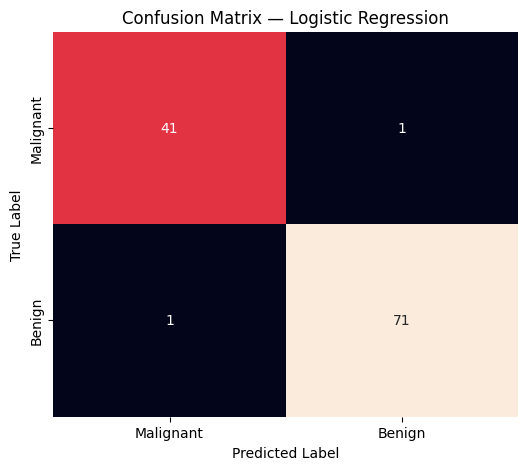

In [21]:
# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "Malignant",
        "Benign"
    ],
    yticklabels=[
        "Malignant",
        "Benign"
    ]
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## 12. ROC Curve for the Best Model

The ROC curve illustrates the ability of the selected model to distinguish between malignant and benign cases across different classification thresholds.

The curve is calculated using the final evaluation on the unseen test set.

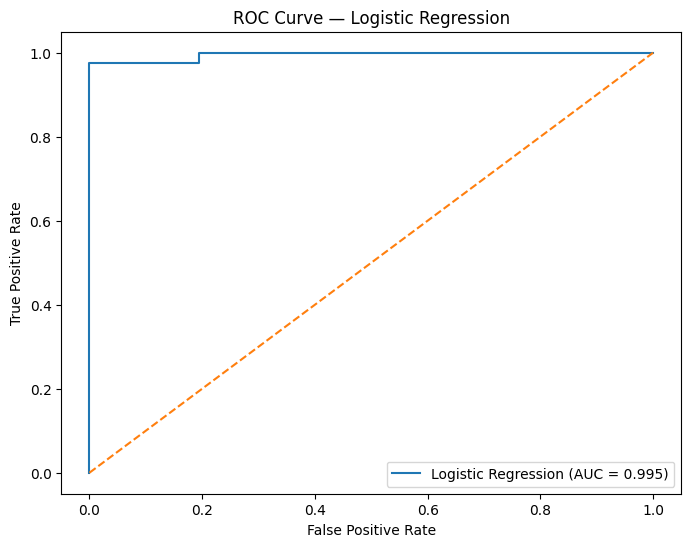

In [22]:
# Calculate the ROC curve
fpr, tpr, _ = roc_curve(
    y_test_malignant,
    y_prob_malignant
)

# Calculate the final ROC-AUC score
auc_score = roc_auc_score(
    y_test_malignant,
    y_prob_malignant
)

plt.figure(figsize=(8, 6))

# Plot the ROC curve
plt.plot(
    fpr,
    tpr,
    label=(
        f"{best_model_name} "
        f"(AUC = {auc_score:.3f})"
    )
)

# Plot the random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    f"ROC Curve — {best_model_name}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## 13. Logistic Regression Feature Analysis

Logistic Regression coefficients are examined to identify the features with the strongest influence on the model's predictions.

Because the input features are standardized, coefficient magnitudes can be compared across features.

This analysis is performed specifically for the Logistic Regression model.

In [23]:
# Retrieve the Logistic Regression pipeline
logistic_pipeline = models["Logistic Regression"]

# Train the model on the complete training set
logistic_pipeline.fit(
    X_train,
    y_train
)

# Extract the trained Logistic Regression model
logistic_model = logistic_pipeline.named_steps["model"]

In [24]:
# Extract Logistic Regression coefficients
coefficients = logistic_model.coef_[0]

# Create a DataFrame containing feature coefficients
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Absolute Coefficient": np.abs(coefficients)
})

# Sort features by coefficient magnitude
feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute Coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


### Feature Importance Visualization

The following chart shows the 10 features with the largest Logistic Regression coefficient magnitudes.

Positive coefficients increase the model's tendency toward the Benign class, while negative coefficients increase the model's tendency toward the Malignant class.

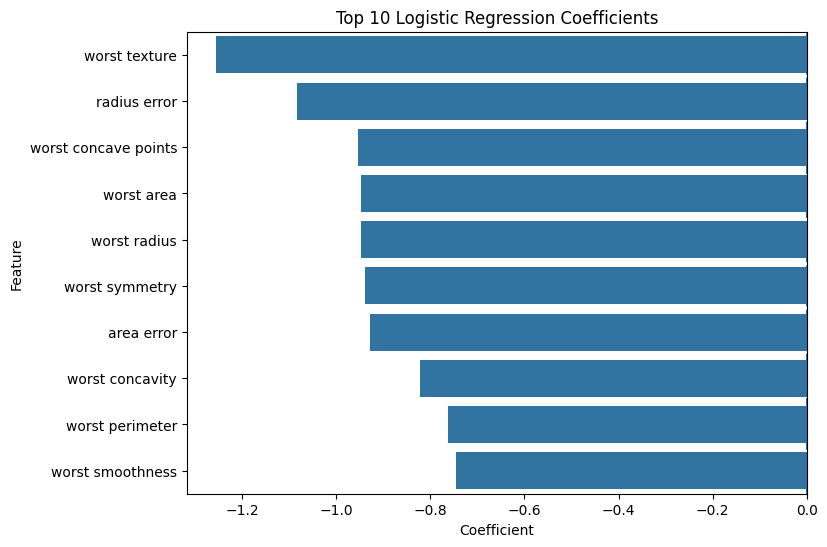

In [25]:
# Select the 10 features with the largest coefficient magnitudes
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top 10 Logistic Regression Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

# Add a reference line at zero
plt.axvline(
    x=0,
    linestyle="--"
)

plt.show()

## 14. Conclusion

This project evaluated five machine learning models for breast cancer classification:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine

The models were compared using stratified 5-fold cross-validation on the training data. Accuracy, precision, recall, F1-score, and ROC-AUC were used as evaluation metrics, with malignant cases treated as the class of interest.

Logistic Regression achieved the highest mean cross-validation ROC-AUC and was selected as the final model.

On the unseen test set, the selected model achieved an accuracy of 98.25% and a ROC-AUC of 99.54%. For malignant cases, precision, recall, and F1-score were all 97.62%.

Logistic Regression coefficients were also analyzed to identify the features with the strongest influence on the model's predictions.

Overall, this project demonstrates a complete and reproducible machine learning workflow, from exploratory data analysis and model comparison to final evaluation and feature analysis.

The results should not be interpreted as evidence of clinical diagnostic performance. This project uses a benchmark dataset and is intended for educational and machine learning practice purposes.